Files inside train_features/duwk/
  B02.tif
  B03.tif
  B04.tif
  B08.tif

FILE: B02.tif
  Size:            512 x 512 pixels
  Number of bands: 1
  CRS:             EPSG:32720
  Resolution:      (10.0, 10.0)
  Data type:       ('uint16',)
  NoData value:    0.0
  Bounds:          BoundingBox(left=415370.0, bottom=9078515.0, right=420490.0, top=9083635.0)

  Pixel Statistics:
    Min:             398.0000
    Max:             18384.0000
    Mean:            2861.2844
    Std:             3894.9590
    % zero pixels:   0.00%
    First 10 unique: [398. 403. 405. 407. 408. 410. 412. 413. 414. 415.]

FILE: B03.tif
  Size:            512 x 512 pixels
  Number of bands: 1
  CRS:             EPSG:32720
  Resolution:      (10.0, 10.0)
  Data type:       ('uint16',)
  NoData value:    0.0
  Bounds:          BoundingBox(left=415370.0, bottom=9078515.0, right=420490.0, top=9083635.0)

  Pixel Statistics:
    Min:             376.0000
    Max:             17152.0000
    Mean:            2751.1514
 

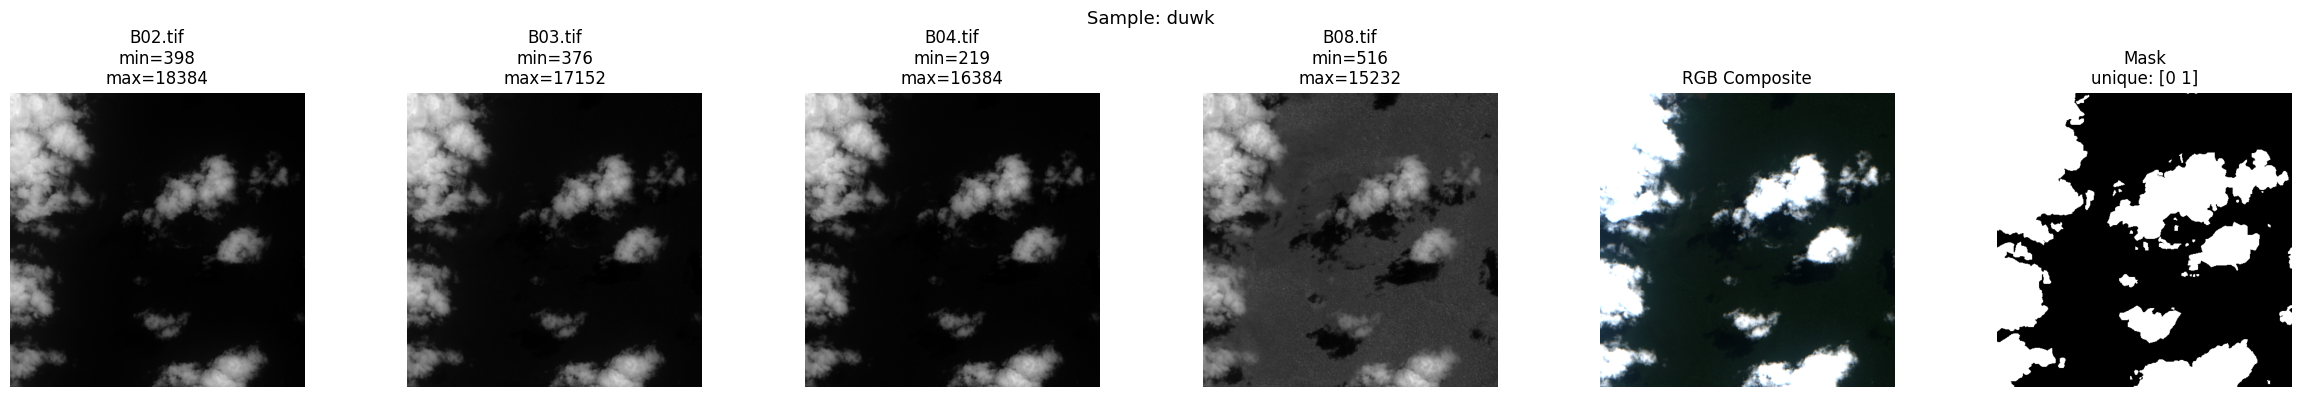

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
#  YOUR PATHS — update the sample name to any folder in train_features
# ============================================================

BASE_DIR       = r'D:\ML\env\notebook\data'
SAMPLE_NAME    = 'duwk'                        # change to any sample folder name

FEATURES_DIR   = os.path.join(BASE_DIR, 'train_features', SAMPLE_NAME)
MASK_PATH      = os.path.join(BASE_DIR, 'train_labels', f'{SAMPLE_NAME}.tif')

# ============================================================
#  Check what files are inside the sample folder
# ============================================================

print("=" * 60)
print(f"Files inside train_features/{SAMPLE_NAME}/")
print("=" * 60)
for f in sorted(os.listdir(FEATURES_DIR)):
    print(f"  {f}")
print()

# ============================================================
#  Inspect each band file
# ============================================================

def inspect_tif(filepath, label=""):
    print("=" * 60)
    print(f"FILE: {label or os.path.basename(filepath)}")
    print("=" * 60)
    with rasterio.open(filepath) as src:
        print(f"  Size:            {src.width} x {src.height} pixels")
        print(f"  Number of bands: {src.count}")
        print(f"  CRS:             {src.crs}")
        print(f"  Resolution:      {src.res}")
        print(f"  Data type:       {src.dtypes}")
        print(f"  NoData value:    {src.nodata}")
        print(f"  Bounds:          {src.bounds}")

        print(f"\n  Pixel Statistics:")
        for i in range(1, src.count + 1):
            data = src.read(i).astype(np.float32)
            valid = data[data != src.nodata] if src.nodata is not None else data.flatten()
            print(f"    Min:             {valid.min():.4f}")
            print(f"    Max:             {valid.max():.4f}")
            print(f"    Mean:            {valid.mean():.4f}")
            print(f"    Std:             {valid.std():.4f}")
            print(f"    % zero pixels:   {(valid == 0).sum() / valid.size * 100:.2f}%")
            print(f"    First 10 unique: {np.unique(valid)[:10]}")
    print()

# Inspect all band files in the sample folder
band_files = sorted(os.listdir(FEATURES_DIR))
band_files = [f for f in band_files if f.endswith('.tif')]

for band in band_files:
    inspect_tif(os.path.join(FEATURES_DIR, band), label=band)

# Inspect the mask
inspect_tif(MASK_PATH, label=f'MASK — {SAMPLE_NAME}.tif')

# ============================================================
#  Visualize bands + RGB + mask
# ============================================================

def visualize_sample(features_dir, band_files, mask_path):
    bands_data = []
    for b in band_files:
        with rasterio.open(os.path.join(features_dir, b)) as src:
            bands_data.append(src.read(1).astype(np.float32))

    with rasterio.open(mask_path) as src:
        mask_data = src.read(1)

    n = len(band_files)
    fig, axes = plt.subplots(1, n + 2, figsize=(4 * (n + 2), 4))

    # Each band
    for i, (data, name) in enumerate(zip(bands_data, band_files)):
        axes[i].imshow(data, cmap='gray')
        axes[i].set_title(f'{name}\nmin={data.min():.0f}\nmax={data.max():.0f}')
        axes[i].axis('off')

    # RGB composite — works if you have at least 3 bands
    # adjust indices [2],[1],[0] if your band order is different
    if len(bands_data) >= 3:
        r = bands_data[2]
        g = bands_data[1]
        b = bands_data[0]
        rgb = np.stack([r, g, b], axis=-1)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        rgb = np.clip(rgb * 3, 0, 1)
        axes[n].imshow(rgb)
        axes[n].set_title('RGB Composite')
        axes[n].axis('off')

    # Mask
    axes[n + 1].imshow(mask_data, cmap='gray')
    axes[n + 1].set_title(f'Mask\nunique: {np.unique(mask_data)}')
    axes[n + 1].axis('off')

    plt.suptitle(f'Sample: {SAMPLE_NAME}', fontsize=13)
    plt.tight_layout()
    plt.savefig('inspection_output.png', dpi=150, bbox_inches='tight')
    print("Saved → inspection_output.png")
    plt.show()

visualize_sample(FEATURES_DIR, band_files, MASK_PATH)